In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/PHL_dataset.csv')

print(df.head())
df.info()

FileNotFoundError: [Errno 2] No such file or directory: '/content/PHL_dataset.csv'

In [ ]:
df.shape

(5599, 118)

In [ ]:
df.columns

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
cols_to_keep = [
    'P_HABITABLE',    # The "Answer Key": 0 = Non-Habitable, 1 = Conservatively Habitable, 2 = Optimistically Habitable.

    # --- PLANET FEATURES (The Environment) ---
    'P_RADIUS',       # Planet Radius (in Earth radii).
    'P_MASS',         # Planet Mass (in Earth masses).
    'P_GRAVITY',      # Surface Gravity.
    'P_PERIOD',       # Orbital Period (Year length).
    'P_FLUX',         # Insolation Flux. The total energy received from the star relative to Earth from sun.
    'P_TEMP_EQUIL',   # Equilibrium Temperature (Kelvin).

    # --- STAR FEATURES (The Source of Energy) ---
    'S_MASS',         # Star Mass. Determines the star's lifespan.
    'S_RADIUS',       # Star Radius. Used with Luminosity to determine the star's energy density and size of the Habitable Zone.
    'S_TEMPERATURE',  # Star Temperature (Effective). Determines the type of light emitted.
    'S_LUMINOSITY',   # Star Luminosity. The total power output of the star in comp.to sun.
]
df = df[[col for col in cols_to_keep if col in df.columns]]

In [ ]:
df.shape

(5599, 11)

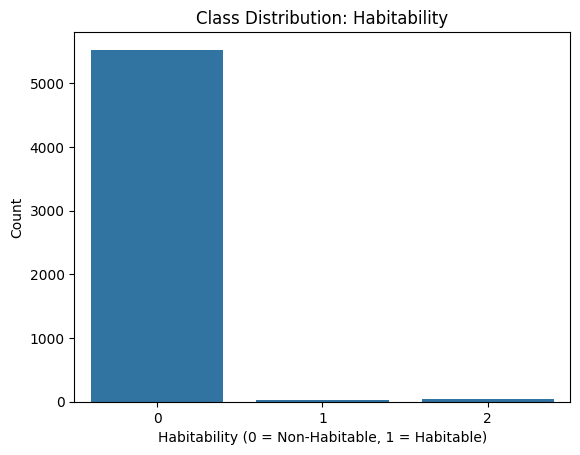

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='P_HABITABLE', data=df)
plt.title("Class Distribution: Habitability")
plt.xlabel("Habitability (0 = Non-Habitable, 1 = Habitable)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Binarize the 'P_HABITABLE' column based on the logic: if 0, then 0, otherwise 1
df['P_HABITABLE'] = df['P_HABITABLE'].apply(lambda x: 0 if x == 0 else 1)

In [ ]:
df['P_HABITABLE'].value_counts()

,count
P_HABITABLE,
0,5529
1,70


Identify missing values

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print('Columns with Missing Values :')
print(missing_df.head(30))

Columns with Missing Values :
               Missing Values  Percentage
P_PERIOD                  249    4.447223
P_FLUX                    234    4.179318
P_TEMP_EQUIL              234    4.179318
S_LUMINOSITY              233    4.161457
S_RADIUS                  232    4.143597
S_TEMPERATURE             219    3.911413
P_MASS                      7    0.125022
P_RADIUS                    7    0.125022
P_GRAVITY                   7    0.125022
S_MASS                      4    0.071441


In [ ]:
df.head()

,P_HABITABLE,P_RADIUS,P_MASS,P_GRAVITY,P_PERIOD,P_FLUX,P_TEMP_EQUIL,S_MASS,S_RADIUS,S_TEMPERATURE,S_LUMINOSITY
0,0,13.90,250.00,1.293929,NaN,NaN,NaN,0.10,NaN,NaN,NaN
1,0,2.90,16.60,1.973841,31.884000,20.490365,541.98483,1.10,1.03,5779.0,0.814704
2,0,2.11,5.10,1.145527,6.883376,238.528680,1001.11710,0.98,0.97,5698.0,1.096478
3,0,3.52,12.20,0.984633,1.921036,353.357260,1104.46820,0.89,0.82,5060.0,0.299226
4,0,2.07,4.94,1.152886,11.119907,51.163853,681.30334,0.87,0.79,5240.0,0.424620


In [ ]:
df.isnull().sum()

,0
P_HABITABLE,0
P_RADIUS,7
P_MASS,7
P_GRAVITY,7
P_PERIOD,249
P_FLUX,234
P_TEMP_EQUIL,234
S_MASS,4
S_RADIUS,232
S_TEMPERATURE,219


In [ ]:
df = df[df.isnull().mean(axis=1) < 0.5]


In [ ]:
df.shape

(5401, 11)

In [ ]:
df.describe()

,P_HABITABLE,P_RADIUS,P_MASS,P_GRAVITY,P_PERIOD,P_FLUX,P_TEMP_EQUIL,S_MASS,S_RADIUS,S_TEMPERATURE,S_LUMINOSITY
count,5401.000000,5394.000000,5394.000000,5394.000000,5.350000e+03,5.365000e+03,5365.000000,5397.000000,5367.000000,5380.000000,5.366000e+03
mean,0.012961,5.560155,430.631404,3.922390,7.994082e+04,8.430605e+02,792.985586,0.969546,1.545746,5430.369987,8.007960e+00
std,0.113115,5.294594,2396.200472,14.166349,5.498596e+06,1.745120e+04,484.434177,0.415540,4.197689,1777.910335,1.110798e+02
min,0.000000,0.310000,0.020000,0.038086,9.070629e-02,3.289901e-10,1.084914,0.010000,0.010000,415.000000,8.128305e-07
25%,0.000000,1.750000,3.955000,1.024179,4.465382e+00,1.053177e+01,456.758880,0.810000,0.780000,4942.750000,3.580964e-01
50%,0.000000,2.720000,8.400000,1.165000,1.156951e+01,6.735305e+01,727.306290,0.950000,0.960000,5555.000000,8.590135e-01
75%,0.000000,11.265000,135.296685,1.526421,4.150555e+01,2.923345e+02,1049.902400,1.100000,1.250000,5902.000000,2.058263e+00
max,1.000000,77.342000,89700.000000,387.976070,4.020000e+08,8.793103e+05,7800.730100,10.940000,109.460000,57000.000000,6.309573e+03


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5401 entries, 1 to 5597
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   P_HABITABLE    5401 non-null   int64  
 1   P_RADIUS       5394 non-null   float64
 2   P_MASS         5394 non-null   float64
 3   P_GRAVITY      5394 non-null   float64
 4   P_PERIOD       5350 non-null   float64
 5   P_FLUX         5365 non-null   float64
 6   P_TEMP_EQUIL   5365 non-null   float64
 7   S_MASS         5397 non-null   float64
 8   S_RADIUS       5367 non-null   float64
 9   S_TEMPERATURE  5380 non-null   float64
 10  S_LUMINOSITY   5366 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 506.3 KB


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
y = df['P_HABITABLE']
X = df.drop(columns=['P_HABITABLE'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X

,P_RADIUS,P_MASS,P_GRAVITY,P_PERIOD,P_FLUX,P_TEMP_EQUIL,S_MASS,S_RADIUS,S_TEMPERATURE,S_LUMINOSITY
1,2.90,16.60000,1.973841,31.884000,20.490365,541.98483,1.10,1.03,5779.0,0.814704
2,2.11,5.10000,1.145527,6.883376,238.528680,1001.11710,0.98,0.97,5698.0,1.096478
3,3.52,12.20000,0.984633,1.921036,353.357260,1104.46820,0.89,0.82,5060.0,0.299226
4,2.07,4.94000,1.152886,11.119907,51.163853,681.30334,0.87,0.79,5240.0,0.424620
5,2.76,13.20000,1.732829,7.493134,29.913640,595.75408,0.68,0.67,4227.0,0.129122
...,...,...,...,...,...,...,...,...,...,...
5592,5.44,26.10000,0.881947,3.770150,197.234610,954.65289,0.84,0.82,5066.4,0.394457
5594,13.40,581.62598,3.239173,3999.000000,0.123796,150.37253,1.21,1.85,5701.0,3.228494
5595,2.49,17.20000,2.774149,146.050000,7.568789,417.87626,1.25,1.54,5861.0,2.471724
5596,3.90,11.30000,0.742932,29.334340,17.899396,523.80007,0.99,0.95,5498.0,0.579429


In [26]:
from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy='median')

imputer.fit(X_train)

# The output is a numpy array, so we wrap it back into a DataFrame
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Verification
print("Missing values in Train:", X_train_imputed.isnull().sum().sum())
print("Missing values in Test:", X_test_imputed.isnull().sum().sum())

Missing values in Train: 0
Missing values in Test: 0


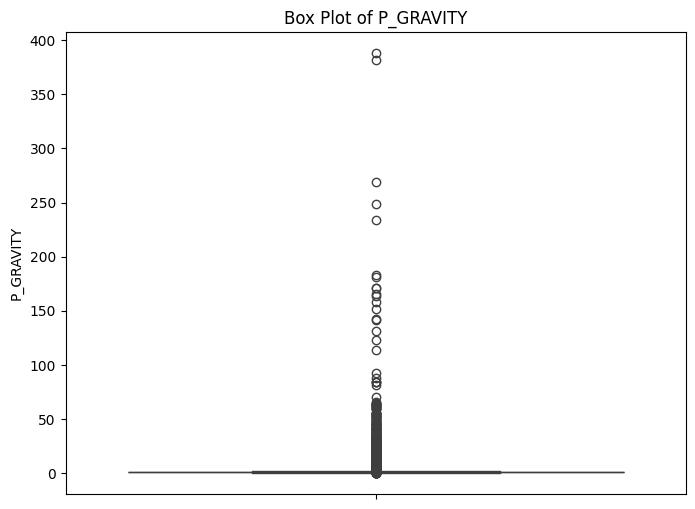

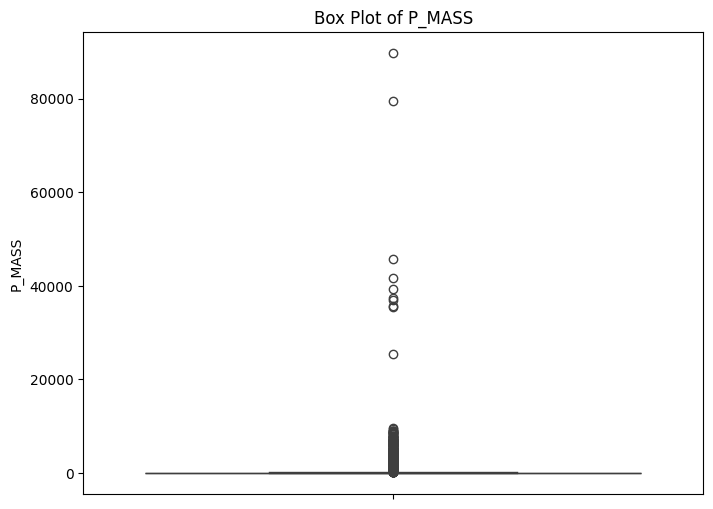

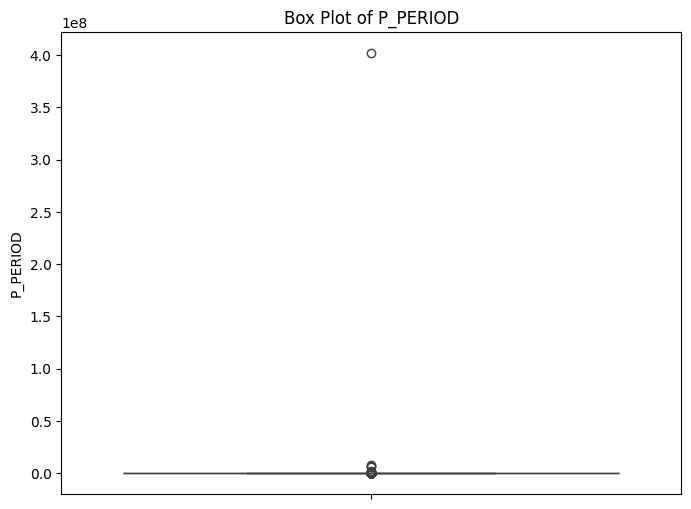

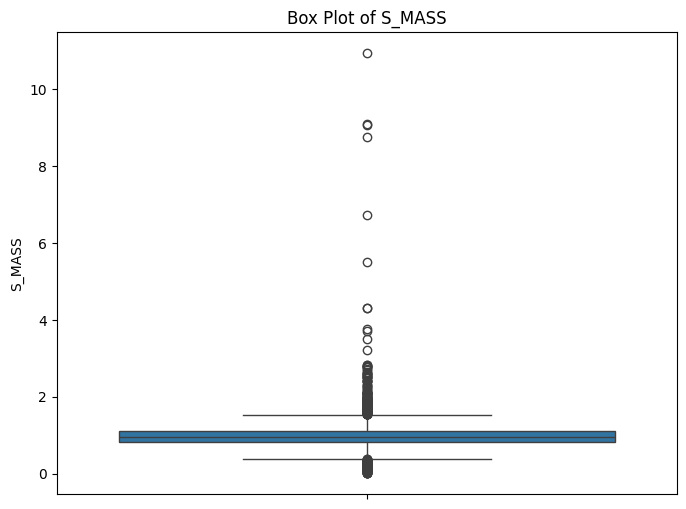

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Based on the previous outlier detection, these columns show significant outliers
key_numerical_cols = [ 'P_GRAVITY', 'P_MASS', 'P_PERIOD', 'S_MASS']

for col in key_numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


In [39]:
#Calculate Q1, Q3, and IQR on TRAINING Data Only
Q1 = X_train_imputed.quantile(0.25)
Q3 = X_train_imputed.quantile(0.75)
IQR = Q3 - Q1

#Define Lower and Upper Limits
lower_limits = Q1 - 1.5 * IQR
upper_limits = Q3 + 1.5 * IQR

#Apply Capping to BOTH Train and Test
X_train_capped = X_train_imputed.clip(lower=lower_limits, upper=upper_limits, axis=1)
X_test_capped = X_test_imputed.clip(lower=lower_limits, upper=upper_limits, axis=1)

# Verification
print("P_MASS Example:")
print(f"Max Value Before Capping: {X_train_imputed['P_MASS'].max()}")
print(f"Max Value After Capping:  {X_train_capped['P_MASS'].max()}")
print(f"Upper Limit Used:         {upper_limits['P_MASS']}")

P_MASS Example:
Max Value Before Capping: 89700.0
Max Value After Capping:  335.8309750000001
Upper Limit Used:         335.8309750000001


In [51]:
skewness = X_train_capped.skew()
skewed_cols = skewness[abs(skewness) > 1].index.tolist()

# 2. Apply Log Transform to BOTH Train and Test
X_train_log = X_train_capped.copy()
X_test_log = X_test_capped.copy()

X_train_log[skewed_cols] = np.log1p(X_train_capped[skewed_cols])
X_test_log[skewed_cols] = np.log1p(X_test_capped[skewed_cols])


In [47]:
X_train_log.corr()

,P_HABITABLE,P_RADIUS,P_MASS,P_GRAVITY,P_PERIOD,P_FLUX,P_TEMP_EQUIL,S_MASS,S_RADIUS,S_TEMPERATURE,S_LUMINOSITY
P_HABITABLE,1.000000,-0.083450,-0.070854,-0.028077,0.066895,-0.089079,-0.143131,-0.193111,-0.168211,-0.206385,-0.107449
P_RADIUS,-0.083450,1.000000,0.893801,0.408321,0.397689,0.140495,-0.015648,0.401746,0.465869,0.175154,0.420270
P_MASS,-0.070854,0.893801,1.000000,0.699347,0.443745,0.086318,-0.072049,0.380034,0.441076,0.121359,0.414935
P_GRAVITY,-0.028077,0.408321,0.699347,1.000000,0.306533,-0.014661,-0.106194,0.203367,0.234645,0.010210,0.234394
P_PERIOD,0.066895,0.397689,0.443745,0.306533,1.000000,-0.502275,-0.669976,0.195295,0.261695,0.013893,0.255286
P_FLUX,-0.089079,0.140495,0.086318,-0.014661,-0.502275,1.000000,0.919514,0.325374,0.290583,0.362550,0.305035
P_TEMP_EQUIL,-0.143131,-0.015648,-0.072049,-0.106194,-0.669976,0.919514,1.000000,0.318087,0.269173,0.378644,0.281363
S_MASS,-0.193111,0.401746,0.380034,0.203367,0.195295,0.325374,0.318087,1.000000,0.888663,0.747621,0.788347
S_RADIUS,-0.168211,0.465869,0.441076,0.234645,0.261695,0.290583,0.269173,0.888663,1.000000,0.589077,0.872684
S_TEMPERATURE,-0.206385,0.175154,0.121359,0.010210,0.013893,0.362550,0.378644,0.747621,0.589077,1.000000,0.527636


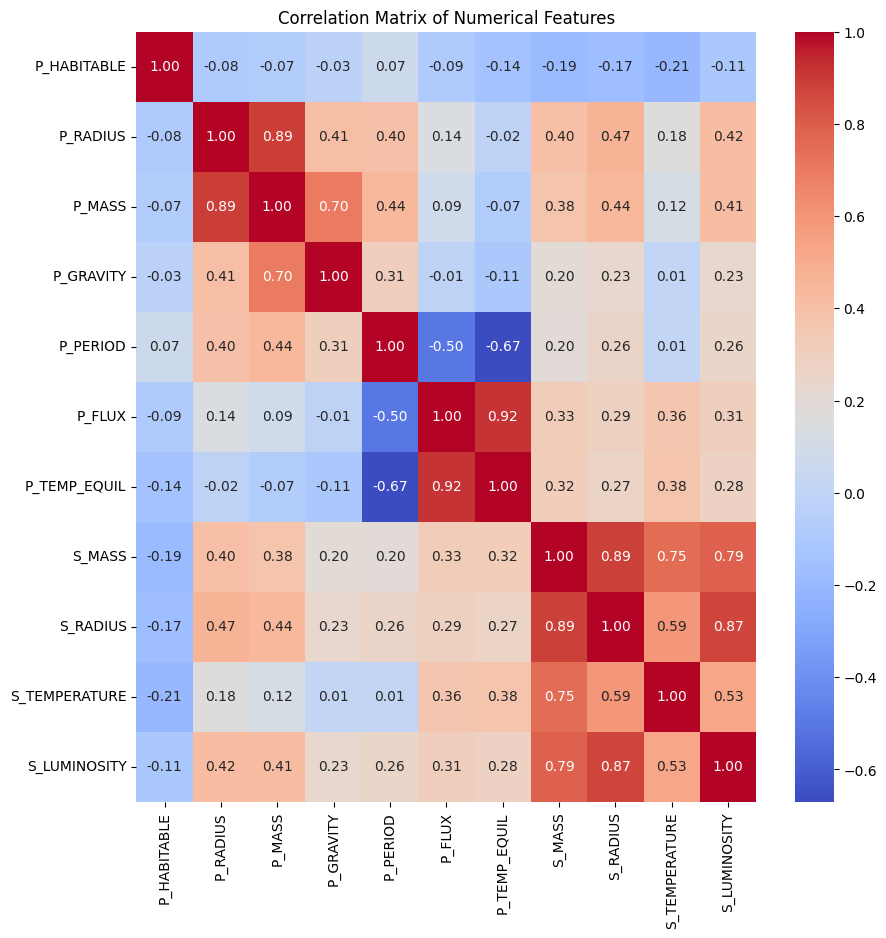

In [49]:
plt.figure(figsize=(10, 10))
sns.heatmap(X_train_log.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

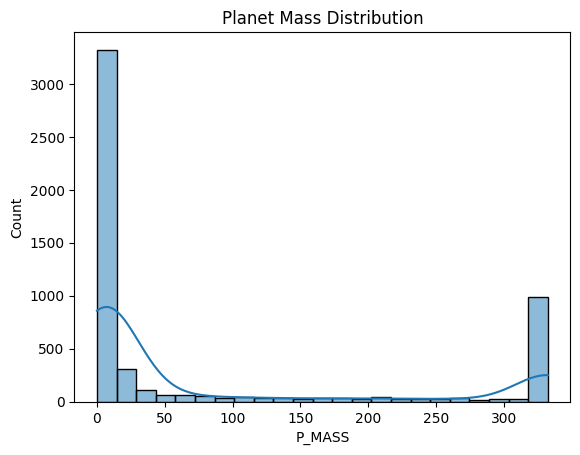

In [44]:
sns.histplot(df['P_MASS'], kde=True)
plt.title("Planet Mass Distribution")
plt.show()


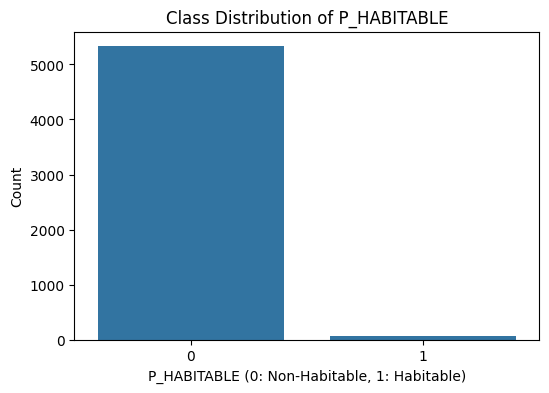

In [45]:
y = df['P_HABITABLE']
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution of P_HABITABLE')
plt.xlabel('P_HABITABLE (0: Non-Habitable, 1: Habitable)')
plt.ylabel('Count')
plt.show()

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.41247826 0.31071335]


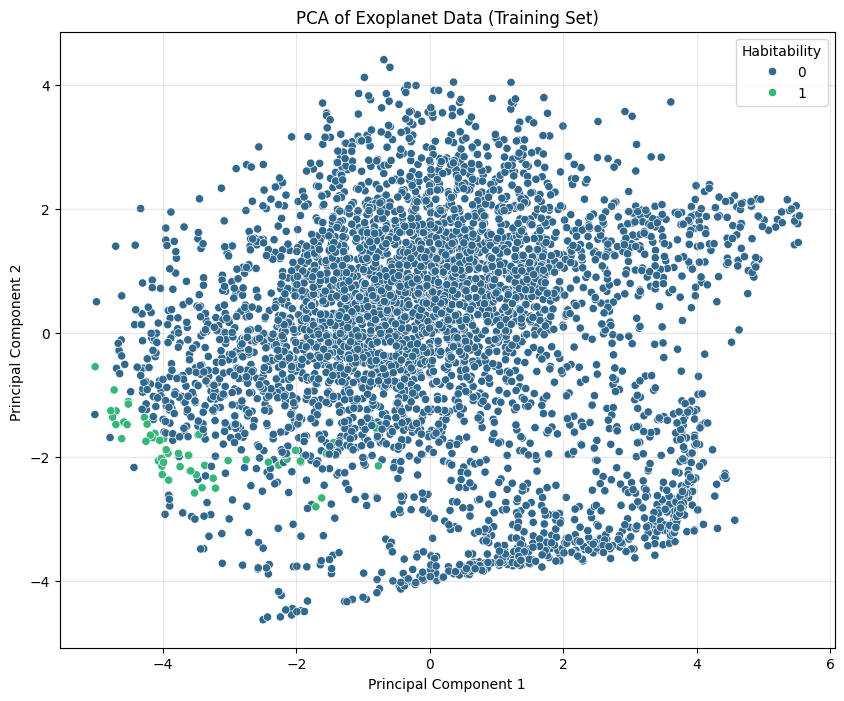

In [57]:
# Ensure you use y_train because X_pca corresponds to the Training set
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train, palette='viridis')

# Add informative labels
plt.title('PCA of Exoplanet Data (Training Set)')
plt.xlabel(f'Principal Component 1')
plt.ylabel(f'Principal Component 2 ')
plt.legend(title='Habitability', loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

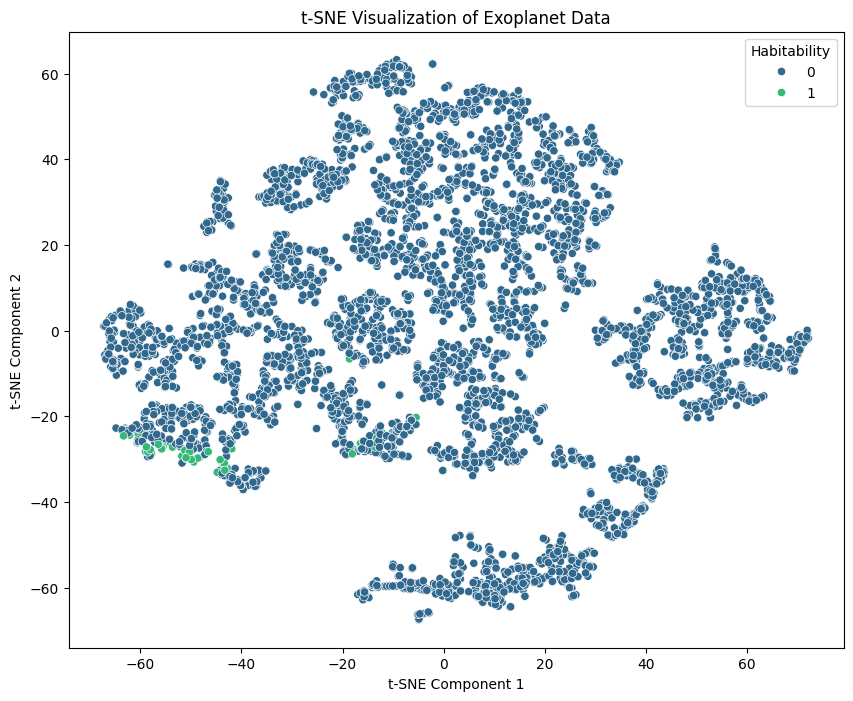

In [61]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Initialize t-SNE
# perplexity: represents the number of neighbors to consider (usually 30-50).
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

# 2. Fit and Transform the scaled training data
X_tsne = tsne.fit_transform(X_train_scaled)

# 3. Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_train, palette='viridis')

plt.title('t-SNE Visualization of Exoplanet Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Habitability')
plt.show()

Baseline model


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Initialize the model
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Use the SCALED data we prepared in the previous steps
log_reg.fit(X_train_scaled, y_train)

# Evaluate on the SCALED test data
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1067
           1       0.37      1.00      0.54        14

    accuracy                           0.98      1081
   macro avg       0.68      0.99      0.76      1081
weighted avg       0.99      0.98      0.98      1081

ROC-AUC Score: 0.9977


In [63]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

# Initialize the SVM
svm = SVC(
    kernel="linear",          # Finds a straight-line boundary between classes
    class_weight="balanced",  # Weights the rare habitable planets more heavily
    probability=True,         # Allows us to calculate ROC-AUC scores later
    random_state=42
)

# Use the SCALED training data
svm.fit(X_train_scaled, y_train)

# Evaluate on the SCALED test data
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("SVM Results:")
print(classification_report(y_test, y_pred_svm))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_svm):.4f}")

SVM Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1067
           1       0.35      1.00      0.52        14

    accuracy                           0.98      1081
   macro avg       0.68      0.99      0.75      1081
weighted avg       0.99      0.98      0.98      1081

ROC-AUC Score: 0.9977


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Initialize the Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
)
# We use X_train_log (the version after imputation, capping, and log-transform)
rf.fit(X_train_log, y_train)

# 3. Evaluate on the PREPROCESSED test data
y_pred_rf = rf.predict(X_test_log)
y_prob_rf = rf.predict_proba(X_test_log)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1067
           1       0.88      1.00      0.93        14

    accuracy                           1.00      1081
   macro avg       0.94      1.00      0.97      1081
weighted avg       1.00      1.00      1.00      1081

ROC-AUC Score: 1.0000
